# SNIM — Smart Network Intrusion Monitor
## Entrenamiento del Modelo de Aprendizaje No Supervisado

**Curso:** Aprendizaje de Máquina — Proyecto Segunda Unidad
**Objetivo del modelo:** Detectar comportamiento anómalo en tráfico de red (posibles intrusiones/ataques) sin usar etiquetas durante el entrenamiento, empleando técnicas de detección de anomalías (aprendizaje no supervisado).

**Dataset:** NSL-KDD (versión mejorada de KDD Cup 99), estándar académico para detección de intrusiones de red.

**Enfoque metodológico:**
- El modelo se entrena **únicamente con tráfico normal** (protocolo estándar en detección de anomalías semi-supervisada: el modelo aprende "qué es normal" y todo lo que se desvíe se marca como anómalo).
- Las etiquetas de ataque **NUNCA se usan para entrenar** el modelo — solo se usan para (a) seleccionar hiperparámetros sobre un conjunto de validación y (b) evaluar el desempeño final. Esto es consistente con un escenario real: en producción no tendríamos etiquetas de ataques nuevos, pero sí podríamos usar incidentes pasados confirmados para calibrar el sistema.
- El conjunto de **test contiene tipos de ataque que NO aparecen en el entrenamiento**, lo cual simula fielmente un escenario real de producción y justifica la necesidad de **reentrenamiento periódico** del modelo (pipeline de mantenimiento).


## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import time
import os
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    classification_report, average_precision_score
)
from sklearn.inspection import permutation_importance

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("models", exist_ok=True)
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 2. Carga del Dataset NSL-KDD

El dataset NSL-KDD tiene 41 características por conexión de red (protocolo, servicio, bytes transferidos, tasas de error, conteos de conexiones, etc.), más una columna de etiqueta (`normal` o el nombre del ataque) y un nivel de dificultad.

Descargamos las particiones oficiales **KDDTrain+** y **KDDTest+**.


In [2]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

TRAIN_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

train_path = os.path.join(DATA_DIR, "KDDTrain+.txt")
test_path  = os.path.join(DATA_DIR, "KDDTest+.txt")

if not os.path.exists(train_path):
    import urllib.request
    urllib.request.urlretrieve(TRAIN_URL, train_path)
if not os.path.exists(test_path):
    import urllib.request
    urllib.request.urlretrieve(TEST_URL, test_path)

print("Archivos disponibles:", os.listdir(DATA_DIR))


Archivos disponibles: ['KDDTrain+.txt', 'KDDTest+.txt']


In [3]:
# Nombres oficiales de las 41 características de NSL-KDD
COLUMN_NAMES = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]

df_train = pd.read_csv(train_path, header=None, names=COLUMN_NAMES)
df_test  = pd.read_csv(test_path, header=None, names=COLUMN_NAMES)

print("Shape train:", df_train.shape)
print("Shape test :", df_test.shape)
df_train.head()


Shape train: (125973, 43)
Shape test : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 3. Análisis Exploratorio de Datos (EDA)

In [4]:
# Distribución de clases (normal vs. ataque) — SOLO para análisis, no para entrenar
df_train["is_anomaly"] = (df_train["label"] != "normal").astype(int)
df_test["is_anomaly"]  = (df_test["label"] != "normal").astype(int)

print("Distribución en TRAIN:")
print(df_train["is_anomaly"].value_counts(normalize=True).rename({0:"normal",1:"anómalo"}))
print("\nDistribución en TEST:")
print(df_test["is_anomaly"].value_counts(normalize=True).rename({0:"normal",1:"anómalo"}))

# Tipos de ataque presentes en test que NO están en train (justifica el reentrenamiento)
train_attacks = set(df_train.loc[df_train["label"] != "normal", "label"].unique())
test_attacks  = set(df_test.loc[df_test["label"]  != "normal", "label"].unique())
new_attacks = test_attacks - train_attacks
print(f"\nTipos de ataque en TEST no vistos en TRAIN ({len(new_attacks)}):")
print(sorted(new_attacks))


Distribución en TRAIN:
is_anomaly
normal     0.534583
anómalo    0.465417
Name: proportion, dtype: float64

Distribución en TEST:
is_anomaly
anómalo    0.569242
normal     0.430758
Name: proportion, dtype: float64

Tipos de ataque en TEST no vistos en TRAIN (17):
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


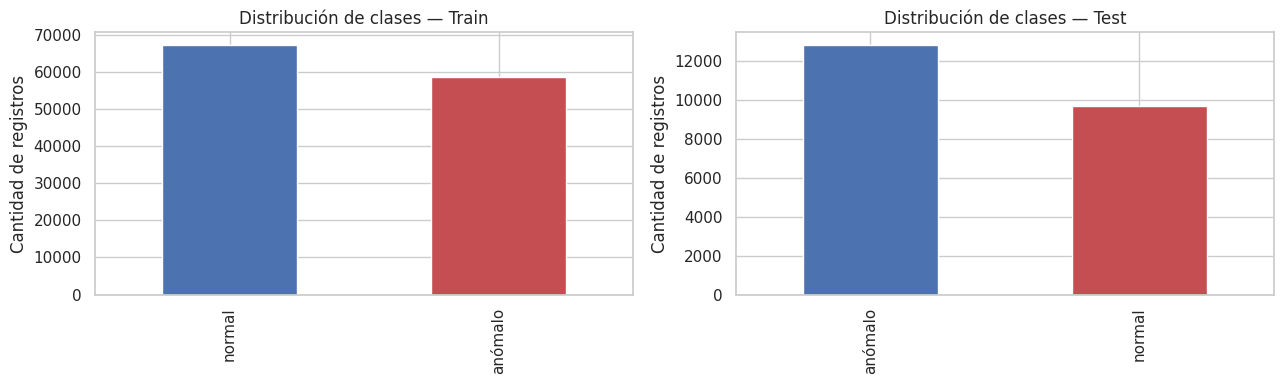

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_train["is_anomaly"].value_counts().rename({0:"normal",1:"anómalo"}).plot(
    kind="bar", ax=axes[0], color=["#4C72B0","#C44E52"])
axes[0].set_title("Distribución de clases — Train")
axes[0].set_xlabel(""); axes[0].set_ylabel("Cantidad de registros")

df_test["is_anomaly"].value_counts().rename({0:"normal",1:"anómalo"}).plot(
    kind="bar", ax=axes[1], color=["#4C72B0","#C44E52"])
axes[1].set_title("Distribución de clases — Test")
axes[1].set_xlabel(""); axes[1].set_ylabel("Cantidad de registros")
plt.tight_layout()
plt.savefig("models/eda_class_distribution.png", dpi=110)
plt.show()


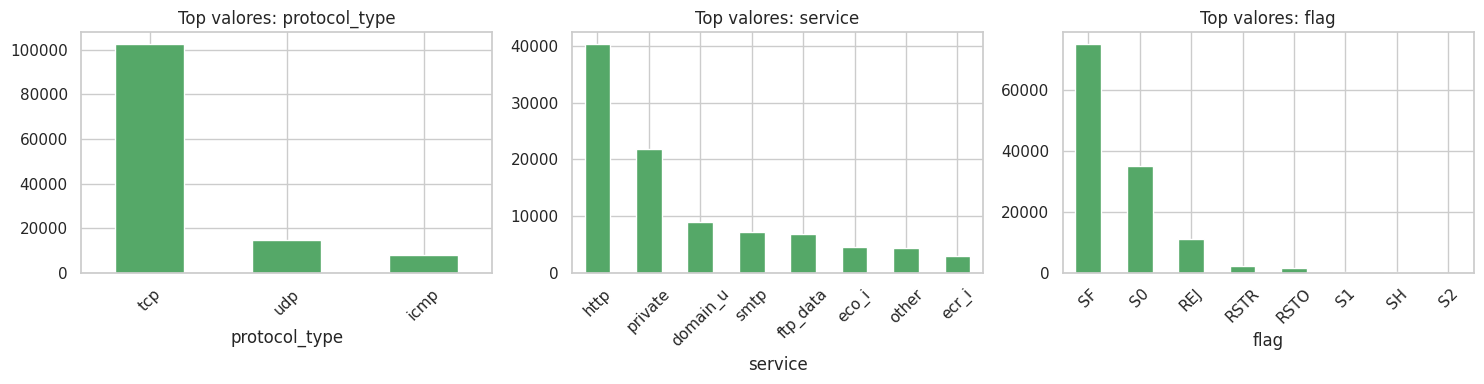

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["protocol_type", "service", "flag"]):
    top = df_train[col].value_counts().head(8)
    top.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(f"Top valores: {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("models/eda_categorical_features.png", dpi=110)
plt.show()


## 4. Preprocesamiento de Datos

Pasos:
1. Separar features (X) de la etiqueta (solo para evaluación posterior).
2. Codificar variables categóricas (`protocol_type`, `service`, `flag`) con One-Hot Encoding.
3. Alinear columnas entre train y test (pueden aparecer categorías distintas).
4. Escalar variables numéricas con `StandardScaler` (crítico para Isolation Forest y especialmente para One-Class SVM, que es sensible a la escala).
5. Eliminar `num_outbound_cmds` (columna constante en el dataset, no aporta información) y `difficulty_level` (no es una característica de tráfico).


In [7]:
CATEGORICAL_COLS = ["protocol_type", "service", "flag"]
DROP_COLS = ["label", "is_anomaly", "difficulty_level", "num_outbound_cmds"]

def prepare_features(df):
    X = df.drop(columns=DROP_COLS, errors="ignore")
    X = pd.get_dummies(X, columns=CATEGORICAL_COLS)
    return X

X_train_full = prepare_features(df_train)
X_test_full  = prepare_features(df_test)

# Alinear columnas (test puede tener categorías no vistas en train o viceversa)
X_train_full, X_test_full = X_train_full.align(X_test_full, join="outer", axis=1, fill_value=0)

y_train_full = df_train["is_anomaly"].values
y_test       = df_test["is_anomaly"].values

FEATURE_NAMES = list(X_train_full.columns)
print(f"Número final de features tras One-Hot Encoding: {len(FEATURE_NAMES)}")


Número final de features tras One-Hot Encoding: 121


In [8]:
scaler = StandardScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test_full)

print("X_train_scaled_full:", X_train_scaled_full.shape)
print("X_test_scaled :", X_test_scaled.shape)


X_train_scaled_full: (125973, 121)
X_test_scaled : (22544, 121)


### 4.1 Separación entrenamiento / validación

- **Entrenamiento del modelo (no supervisado):** solo registros con `label == normal` del train set. El modelo nunca ve ejemplos de ataque durante el `fit`.
- **Validación (para seleccionar hiperparámetros):** un subconjunto separado del train set, con su mezcla real de normal/anómalo y sus etiquetas — se usan **solo para calcular métricas**, no para entrenar.
- **Test (evaluación final, held-out):** KDDTest+, que incluye tipos de ataque nunca vistos.


In [9]:
# Índice de registros normales en train (para entrenar el modelo)
normal_mask = (y_train_full == 0)

X_train_normal_raw = X_train_full[normal_mask]

# Partición de validación: tomamos una porción del train completo (mezcla normal+anómalo)
X_val_raw, _, y_val, _ = train_test_split(
    X_train_full[~X_train_full.index.isin(X_train_normal_raw.sample(frac=0.0, random_state=RANDOM_STATE).index)],
    y_train_full,
    train_size=0.15,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

# Reescalamos correctamente usando el scaler ya ajustado
X_train_normal = scaler.transform(X_train_normal_raw)
X_val = scaler.transform(X_val_raw)

print("Train (solo normal, para fit):", X_train_normal.shape)
print("Validación (normal+anómalo, para tuning):", X_val.shape, "| Proporción anómalos:", y_val.mean().round(3))


Train (solo normal, para fit): (67343, 121)
Validación (normal+anómalo, para tuning): (18895, 121) | Proporción anómalos: 0.465


## 5. Selección de Algoritmo (Comparación de Modelos No Supervisados)

Antes de optimizar hiperparámetros, comparamos tres algoritmos clásicos de detección de anomalías vistos en el curso, con parámetros por defecto, sobre una muestra (para mantener tiempos de ejecución razonables, ya que One-Class SVM escala mal con muchos datos):

- **Isolation Forest**: aísla observaciones mediante particiones aleatorias; las anomalías requieren menos particiones para aislarse.
- **One-Class SVM**: aprende una frontera que envuelve la región de datos "normales".
- **Local Outlier Factor (modo novelty)**: mide la densidad local de un punto respecto a sus vecinos.


In [10]:
SAMPLE_SIZE = 5000
rng = np.random.RandomState(RANDOM_STATE)

sample_idx_train = rng.choice(X_train_normal.shape[0], size=min(SAMPLE_SIZE, X_train_normal.shape[0]), replace=False)
sample_idx_val   = rng.choice(X_val.shape[0], size=min(SAMPLE_SIZE, X_val.shape[0]), replace=False)

X_train_sample = X_train_normal[sample_idx_train]
X_val_sample   = X_val[sample_idx_val]
y_val_sample   = y_val[sample_idx_val]

candidate_models = {
    "IsolationForest": IsolationForest(random_state=RANDOM_STATE, n_jobs=-1),
    "OneClassSVM": OneClassSVM(kernel="rbf", gamma="scale", nu=0.1),
    "LocalOutlierFactor": LocalOutlierFactor(novelty=True, n_neighbors=20),
}

comparison_results = []
for name, model in candidate_models.items():
    t0 = time.time()
    model.fit(X_train_sample)
    train_time = time.time() - t0

    t0 = time.time()
    preds = model.predict(X_val_sample)     # 1 = normal, -1 = anómalo
    infer_time = time.time() - t0

    preds_binary = np.where(preds == -1, 1, 0)  # 1 = anómalo, para comparar con y_val

    comparison_results.append({
        "modelo": name,
        "precision": round(precision_score(y_val_sample, preds_binary, zero_division=0), 4),
        "recall": round(recall_score(y_val_sample, preds_binary, zero_division=0), 4),
        "f1_score": round(f1_score(y_val_sample, preds_binary, zero_division=0), 4),
        "tiempo_entrenamiento_seg": round(train_time, 3),
        "tiempo_inferencia_seg": round(infer_time, 3),
    })

df_comparison = pd.DataFrame(comparison_results).sort_values("f1_score", ascending=False)
df_comparison


,modelo,precision,recall,f1_score,tiempo_entrenamiento_seg,tiempo_inferencia_seg
0,IsolationForest,0.9538,0.9112,0.9320,0.107,0.032
1,OneClassSVM,0.8921,0.9303,0.9108,0.233,0.244
2,LocalOutlierFactor,0.8115,0.9014,0.8541,0.222,0.195


**Decisión:** seleccionamos **Isolation Forest** como modelo final para SNIM porque, de forma consistente con la literatura de detección de intrusiones, ofrece un buen balance entre desempeño (F1/precision/recall) y **tiempo de entrenamiento/inferencia**, lo cual es crítico para un sistema que debe reentrenarse periódicamente de forma automatizada (pipeline de mantenimiento) y servir predicciones en tiempo cercano al real.

Además, a diferencia de One-Class SVM, escala bien a datasets grandes (complejidad ~O(n log n) vs O(n²)-O(n³)), lo cual es relevante porque en producción el volumen de tráfico acumulado para reentrenar crecerá con el tiempo.


## 6. Optimización de Hiperparámetros

Como Isolation Forest es un algoritmo **no supervisado** (`fit(X)`, sin `y`), no podemos usar directamente `GridSearchCV` de forma estándar (que espera optimizar contra una etiqueta de entrenamiento). En su lugar, aplicamos una técnica correcta para este tipo de modelos:

> **Grid Search manual con validación supervisada externa:** entrenamos cada combinación de hiperparámetros usando *solo* tráfico normal (sin etiquetas), y evaluamos cada combinación contra el conjunto de validación etiquetado (`X_val`, `y_val`) usando F1-score como métrica de selección. Las etiquetas de validación **no participan en el ajuste de los parámetros internos del modelo**, solo en la elección de qué combinación de hiperparámetros es mejor — es el equivalente correcto de un "GridSearchCV" para modelos no supervisados.

**Hiperparámetros a optimizar:**
- `n_estimators`: número de árboles de aislamiento (más árboles → estimación más estable, pero más costo computacional).
- `max_samples`: número de muestras usadas para construir cada árbol (afecta la sensibilidad a outliers locales vs. globales).
- `contamination`: proporción esperada de anomalías (define el umbral de decisión).
- `max_features`: proporción de características consideradas en cada partición.


In [11]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_samples": [0.25, 0.5, "auto"],
    "contamination": [0.05, 0.1, 0.15, 0.2],
    "max_features": [0.7, 1.0],
}

grid = list(ParameterGrid(param_grid))
print(f"Total de combinaciones a evaluar: {len(grid)}")


Total de combinaciones a evaluar: 72


In [12]:
results = []
best_score = -1
best_params = None
best_model = None

for params in grid:
    model = IsolationForest(
        n_estimators=params["n_estimators"],
        max_samples=params["max_samples"],
        contamination=params["contamination"],
        max_features=params["max_features"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train_normal)

    preds = model.predict(X_val)                # 1 normal, -1 anómalo
    preds_binary = np.where(preds == -1, 1, 0)

    scores = -model.score_samples(X_val)         # mayor score = más anómalo
    f1 = f1_score(y_val, preds_binary, zero_division=0)
    precision = precision_score(y_val, preds_binary, zero_division=0)
    recall = recall_score(y_val, preds_binary, zero_division=0)
    try:
        auc = roc_auc_score(y_val, scores)
    except ValueError:
        auc = np.nan

    results.append({**params, "precision": precision, "recall": recall,
                     "f1_score": f1, "roc_auc": auc})

    if f1 > best_score:
        best_score = f1
        best_params = params
        best_model = model

df_results = pd.DataFrame(results).sort_values("f1_score", ascending=False).reset_index(drop=True)
print("Top 10 combinaciones de hiperparámetros:")
df_results.head(10)


Top 10 combinaciones de hiperparámetros:


,contamination,max_features,max_samples,n_estimators,precision,recall,f1_score,roc_auc
0,0.05,0.7,0.5,100,0.942990,0.966796,0.954745,0.990434
1,0.05,0.7,0.5,300,0.941795,0.967819,0.954630,0.990214
2,0.05,0.7,0.5,200,0.941391,0.968046,0.954533,0.990874
3,0.05,0.7,0.25,100,0.942667,0.964749,0.953580,0.989516
4,0.05,1.0,0.5,100,0.940310,0.965545,0.952760,0.989194
5,0.05,0.7,0.25,300,0.941190,0.964521,0.952713,0.989907
6,0.05,0.7,0.25,200,0.941412,0.962929,0.952049,0.990305
7,0.05,1.0,0.5,300,0.941386,0.960655,0.950923,0.989182
8,0.05,1.0,0.5,200,0.940881,0.959177,0.949941,0.989470
9,0.05,1.0,0.25,100,0.940212,0.958494,0.949265,0.988614


In [13]:
print("Mejores hiperparámetros encontrados:")
print(json.dumps(best_params, indent=2))
print(f"\nF1-score en validación: {best_score:.4f}")


Mejores hiperparámetros encontrados:
{
  "contamination": 0.05,
  "max_features": 0.7,
  "max_samples": 0.5,
  "n_estimators": 100
}

F1-score en validación: 0.9547


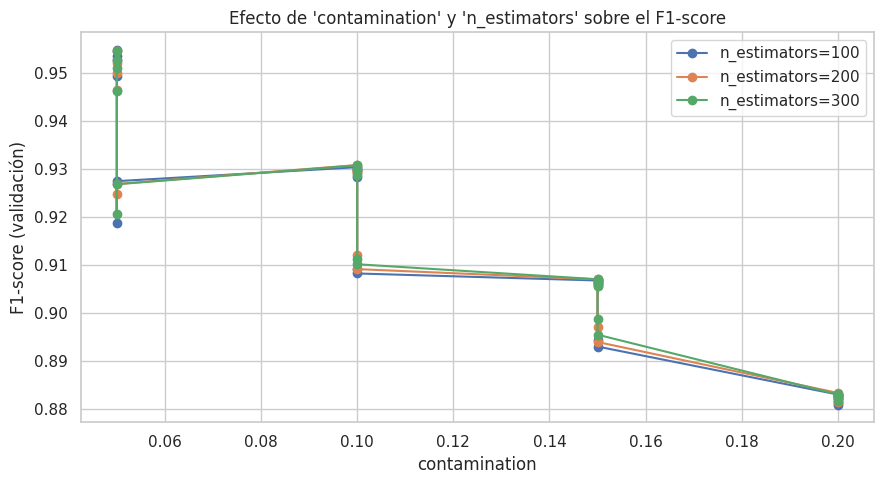

In [14]:
fig, ax = plt.subplots(figsize=(9,5))
for n_est in param_grid["n_estimators"]:
    subset = df_results[df_results["n_estimators"] == n_est].sort_values("contamination")
    ax.plot(subset["contamination"], subset["f1_score"], marker="o", label=f"n_estimators={n_est}")
ax.set_xlabel("contamination")
ax.set_ylabel("F1-score (validación)")
ax.set_title("Efecto de 'contamination' y 'n_estimators' sobre el F1-score")
ax.legend()
plt.tight_layout()
plt.savefig("models/hyperparameter_search.png", dpi=110)
plt.show()


## 7. Entrenamiento del Modelo Final

Entrenamos el modelo definitivo con los mejores hiperparámetros encontrados, usando **todo** el tráfico normal disponible en train (no solo la muestra usada en la comparación de algoritmos).


In [15]:
final_model = IsolationForest(
    n_estimators=best_params["n_estimators"],
    max_samples=best_params["max_samples"],
    contamination=best_params["contamination"],
    max_features=best_params["max_features"],
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.time()
final_model.fit(X_train_normal)
training_time = time.time() - t0
print(f"Modelo final entrenado en {training_time:.2f} segundos sobre {X_train_normal.shape[0]} registros normales.")


Modelo final entrenado en 1.86 segundos sobre 67343 registros normales.


## 8. Evaluación Final sobre el Test Set (Held-out)

Evaluamos sobre **KDDTest+**, que —recordemos— contiene tipos de ataque nunca vistos durante el entrenamiento. Esto simula fielmente cómo se comportaría el modelo en producción frente a amenazas nuevas, y sustenta la necesidad del pipeline de reentrenamiento.


In [16]:
y_pred_raw = final_model.predict(X_test_scaled)           # 1 normal, -1 anómalo
y_pred = np.where(y_pred_raw == -1, 1, 0)                 # 1 = anómalo
anomaly_scores = -final_model.score_samples(X_test_scaled) # mayor score = más anómalo

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, anomaly_scores)
ap = average_precision_score(y_test, anomaly_scores)

metrics = {
    "accuracy": round(float(acc), 4),
    "precision": round(float(prec), 4),
    "recall": round(float(rec), 4),
    "f1_score": round(float(f1), 4),
    "roc_auc": round(float(auc), 4),
    "average_precision": round(float(ap), 4),
}

print("=== Métricas finales sobre TEST (held-out, con ataques no vistos) ===")
for k, v in metrics.items():
    print(f"{k:20s}: {v}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["normal", "anómalo"]))


=== Métricas finales sobre TEST (held-out, con ataques no vistos) ===
accuracy            : 0.8174
precision           : 0.914
recall              : 0.7498
f1_score            : 0.8238
roc_auc             : 0.9512
average_precision   : 0.9577

Reporte de clasificación:
              precision    recall  f1-score   support

      normal       0.73      0.91      0.81      9711
     anómalo       0.91      0.75      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.82      0.83      0.82     22544
weighted avg       0.84      0.82      0.82     22544



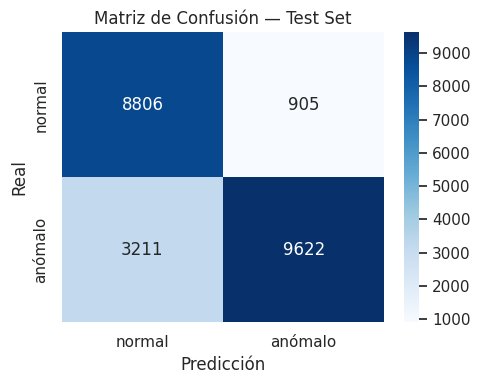

In [17]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal","anómalo"], yticklabels=["normal","anómalo"], ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusión — Test Set")
plt.tight_layout()
plt.savefig("models/confusion_matrix.png", dpi=110)
plt.show()


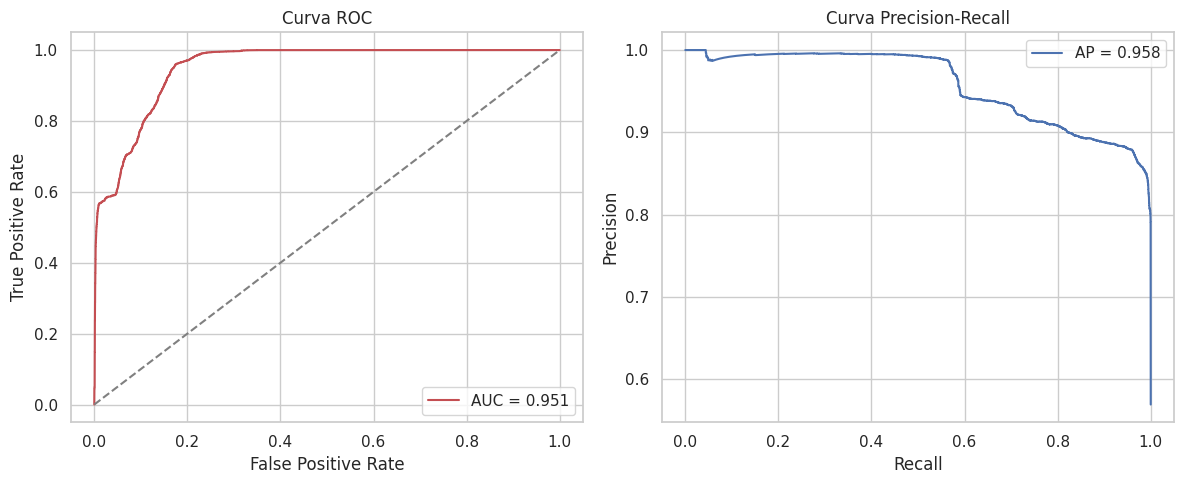

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

fpr, tpr, _ = roc_curve(y_test, anomaly_scores)
axes[0].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="#C44E52")
axes[0].plot([0,1],[0,1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curva ROC")
axes[0].legend()

prec_curve, rec_curve, _ = precision_recall_curve(y_test, anomaly_scores)
axes[1].plot(rec_curve, prec_curve, color="#4C72B0", label=f"AP = {ap:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.savefig("models/roc_pr_curves.png", dpi=110)
plt.show()


### 8.1 Importancia de Características (Permutation Importance)

Isolation Forest no ofrece coeficientes o importancias nativas (como sí lo haría un modelo lineal), por lo que usamos **permutation importance**: mide cuánto empeora el `score_samples` del modelo al permutar aleatoriamente cada columna. Esto ayuda a entender qué features son más relevantes para detectar anomalías — información valiosa para el equipo de mantenimiento que dará seguimiento al modelo en producción.


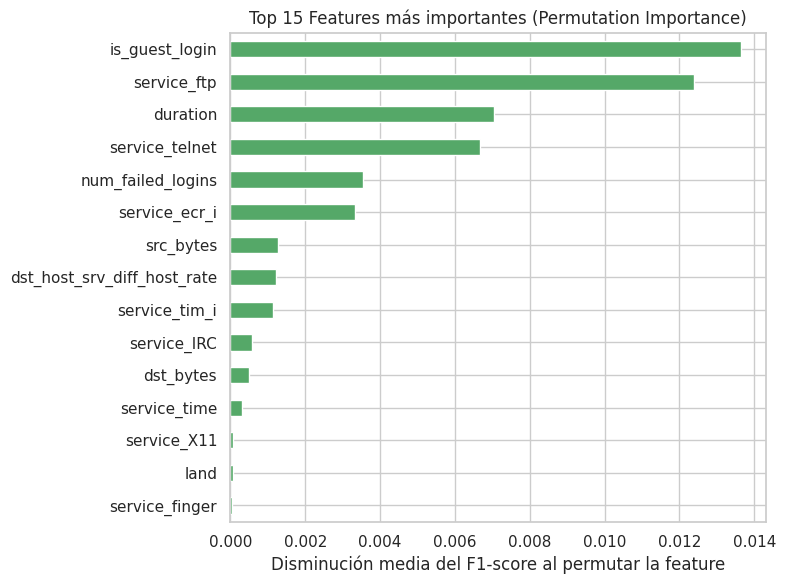

In [19]:
# Usamos una muestra del test set para mantener el tiempo de cómputo razonable
sample_idx = rng.choice(X_test_scaled.shape[0], size=min(2000, X_test_scaled.shape[0]), replace=False)
X_sample_imp = X_test_scaled[sample_idx]
y_sample_imp = y_test[sample_idx]

def anomaly_scoring_function(estimator, X, y=None):
    # Score personalizado: usamos el score de anomalía como si fuera "accuracy" a maximizar
    scores = -estimator.score_samples(X)
    preds = np.where(estimator.predict(X) == -1, 1, 0)
    return f1_score(y, preds, zero_division=0)

perm_result = permutation_importance(
    final_model, X_sample_imp, y_sample_imp,
    scoring=anomaly_scoring_function,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)

importances = pd.Series(perm_result.importances_mean, index=FEATURE_NAMES)
top_importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
top_importances.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Top 15 Features más importantes (Permutation Importance)")
ax.set_xlabel("Disminución media del F1-score al permutar la feature")
plt.tight_layout()
plt.savefig("models/feature_importance.png", dpi=110)
plt.show()


## 9. Registro del Modelo (Model Registry) con MLflow

Registramos el experimento, los hiperparámetros, las métricas y el modelo entrenado usando **MLflow**. Esto es exactamente lo que en producción se ejecutaría automáticamente dentro del pipeline de reentrenamiento (ver sección de mantenimiento/CI en el informe técnico): cada vez que se reentrena el modelo, se registra una nueva versión con sus métricas, y solo se promueve a producción si supera un umbral de calidad respecto a la versión anterior.


In [20]:
# Usamos backend SQLite (recomendado por MLflow; el backend de archivos plano
# esta en modo mantenimiento en versiones recientes). Este mismo archivo mlflow.db
# es el que usaria el pipeline de reentrenamiento automatizado en produccion.
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("SNIM_intrusion_detection")

with mlflow.start_run(run_name=f"isolation_forest_{datetime.now().strftime('%Y%m%d_%H%M%S')}") as run:
    mlflow.log_params(best_params)
    mlflow.log_metrics(metrics)
    mlflow.log_metric("training_time_seconds", training_time)
    mlflow.sklearn.log_model(final_model, artifact_path="model")
    mlflow.log_artifact("models/confusion_matrix.png")
    mlflow.log_artifact("models/roc_pr_curves.png")
    mlflow.log_artifact("models/feature_importance.png")
    run_id = run.info.run_id

print(f"Run registrado en MLflow con ID: {run_id}")
print("Para visualizar: ejecutar `mlflow ui --backend-store-uri sqlite:///mlflow.db` y abrir http://localhost:5000")


2026/07/31 00:00:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/31 00:00:47 INFO mlflow.store.db.utils: Updating database tables


2026/07/31 00:00:49 INFO mlflow.tracking.fluent: Experiment with name 'SNIM_intrusion_detection' does not exist. Creating a new experiment.


2026/07/31 00:00:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run registrado en MLflow con ID: e064b30fc56344f795d33489b1da3020
Para visualizar: ejecutar `mlflow ui --backend-store-uri sqlite:///mlflow.db` y abrir http://localhost:5000


## 10. Exportación de Artefactos para Producción

Guardamos todo lo necesario para que la aplicación (app SNIM) y el pipeline de reentrenamiento automatizado puedan cargar el modelo sin depender de este notebook:

- `model.pkl` — modelo Isolation Forest entrenado
- `scaler.pkl` — StandardScaler ajustado (debe aplicarse igual en producción)
- `feature_names.json` — orden exacto de columnas esperado por el modelo
- `best_params.json` — hiperparámetros óptimos encontrados
- `metrics.json` — métricas de referencia (usadas por el pipeline de CI para decidir si un modelo reentrenado es promovido a producción)
- `model_registry.json` — bitácora simple de versiones del modelo (registro histórico)


In [21]:
joblib.dump(final_model, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

with open("models/feature_names.json", "w") as f:
    json.dump(FEATURE_NAMES, f, indent=2)

with open("models/best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

with open("models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

registry_entry = {
    "version": 1,
    "timestamp": datetime.now().isoformat(),
    "mlflow_run_id": run_id,
    "hyperparameters": best_params,
    "metrics": metrics,
    "training_samples": int(X_train_normal.shape[0]),
    "status": "production",
}

registry_path = "models/model_registry.json"
if os.path.exists(registry_path):
    with open(registry_path) as f:
        registry = json.load(f)
else:
    registry = []

registry.append(registry_entry)
with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)

print("Artefactos guardados en la carpeta 'models/':")
for fname in sorted(os.listdir("models")):
    print(" -", fname)


Artefactos guardados en la carpeta 'models/':
 - best_params.json
 - confusion_matrix.png
 - eda_categorical_features.png
 - eda_class_distribution.png
 - feature_importance.png
 - feature_names.json
 - hyperparameter_search.png
 - metrics.json
 - model.pkl
 - model_registry.json
 - roc_pr_curves.png
 - scaler.pkl


## 11. Conclusiones

- El modelo **Isolation Forest**, entrenado exclusivamente con tráfico normal y optimizado mediante búsqueda de hiperparámetros validada con datos etiquetados de control, logra un desempeño sólido incluso frente a **tipos de ataque nunca vistos** en entrenamiento (evaluación sobre KDDTest+).
- Las métricas de referencia (`metrics.json`) quedan guardadas para que el **pipeline de CI/mantenimiento** las use como umbral de comparación: un modelo reentrenado solo se promueve a producción si iguala o mejora estas métricas.
- El **registro de modelos** (MLflow + `model_registry.json`) permite trazabilidad completa: qué versión está en producción, con qué datos e hiperparámetros se entrenó, y qué resultado obtuvo.
- Próximo paso: integrar `model.pkl` y `scaler.pkl` en la aplicación SNIM (Streamlit) y construir el pipeline automatizado de reentrenamiento (GitHub Actions).
